# Importación del archivo de uso (Datos de Marketing para un Banco) 
https://www.kaggle.com/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset

In [159]:
import kagglehub
    
# Download latest version
path = kagglehub.dataset_download("volodymyrgavrysh/bank-marketing-campaigns-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/sarahivillegas/.cache/kagglehub/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset/versions/1


In [160]:
import pandas as pd
import os
import numpy as np

path_filename = "bank-additional-full.csv"
path_file =  os.path.join(path, path_filename)

df = pd.read_csv(path_file, sep=';')

# Muestra de datos

In [161]:
df.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
37593,68,retired,married,basic.4y,no,no,no,cellular,aug,mon,...,1,999,2,failure,-2.9,92.201,-31.4,0.861,5076.2,no
30988,31,blue-collar,married,basic.9y,no,yes,no,cellular,may,tue,...,3,999,2,failure,-1.8,92.893,-46.2,1.344,5099.1,no
27802,88,retired,divorced,basic.4y,no,no,no,cellular,mar,wed,...,2,999,0,nonexistent,-1.8,92.843,-50.0,1.663,5099.1,yes
10105,42,blue-collar,married,basic.6y,no,yes,no,telephone,jun,thu,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.958,5228.1,no
22249,47,blue-collar,married,basic.6y,no,yes,no,cellular,aug,thu,...,2,999,0,nonexistent,1.4,93.444,-36.1,4.963,5228.1,no


In [162]:
print('Columns names:',df.columns.to_list())

Columns names: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']


# Feature Engineering: Variables alto sesgo

In [163]:
cols_num = ['age', 'pdays',
       'previous', 'cons.price.idx', 'cons.conf.idx',
       'nr.employed', 'duration', 'campaign']


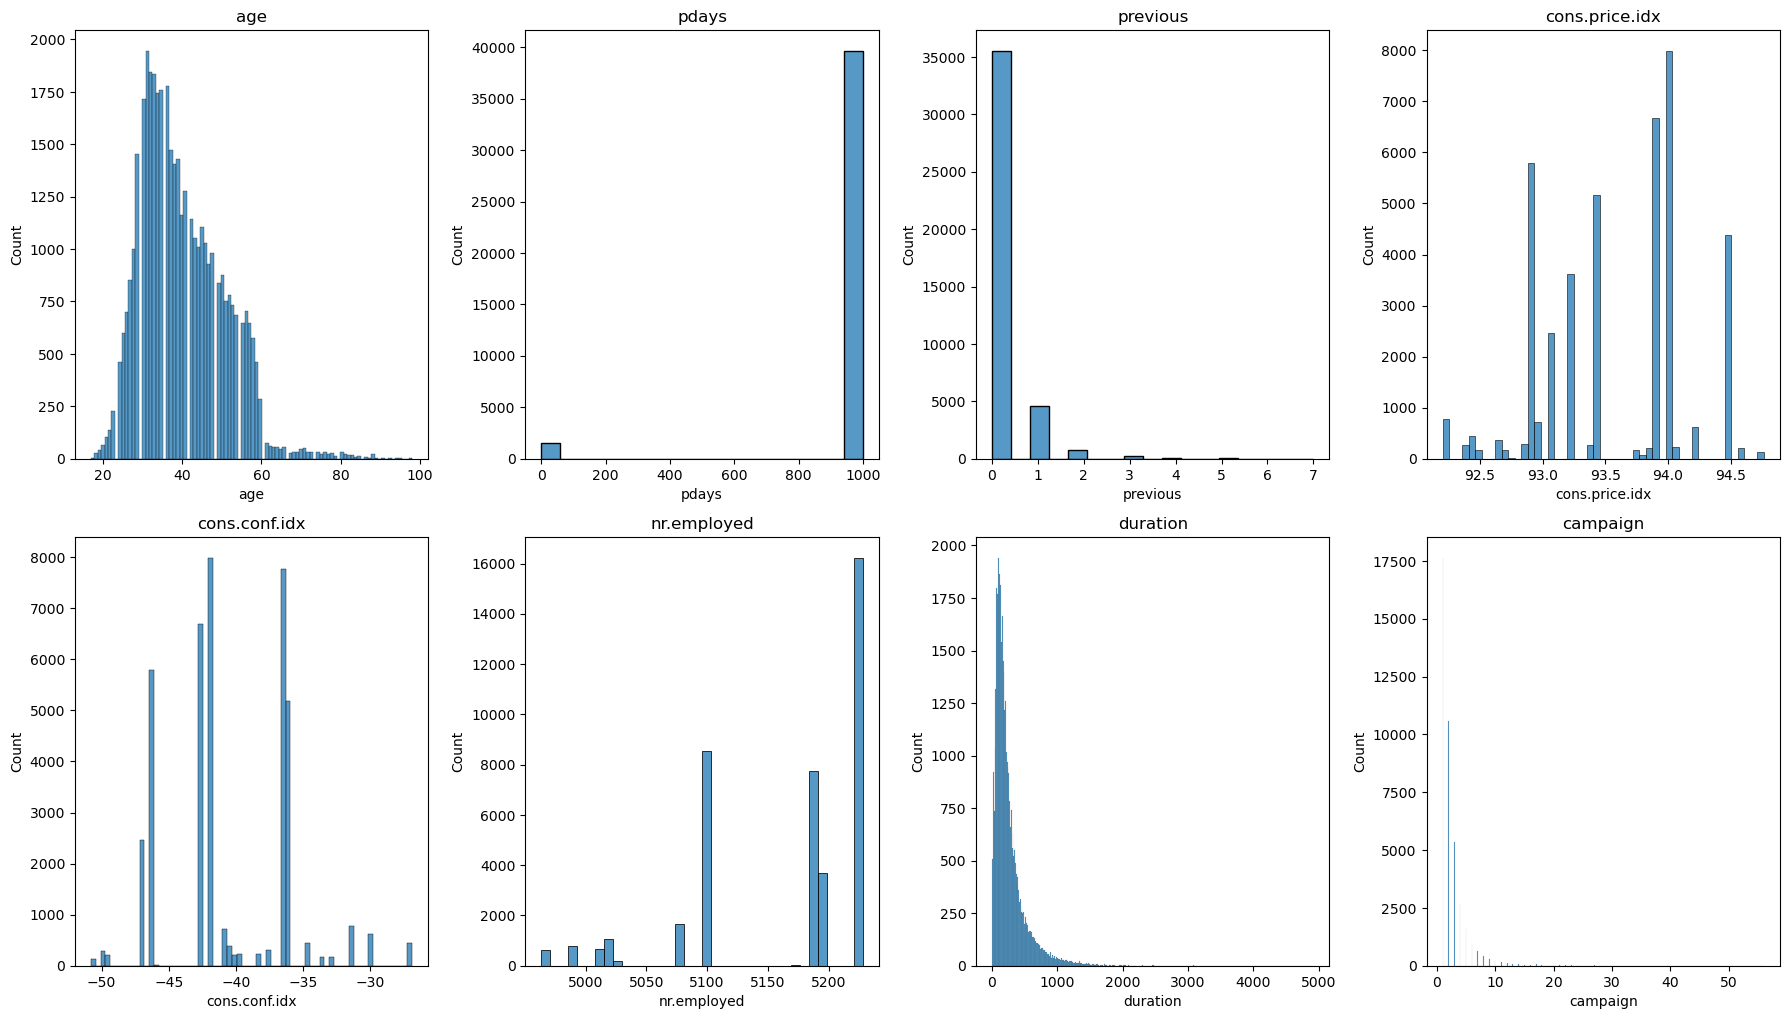

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

# Mantener solo columnas existentes


fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(18,20))

axes = axes.flatten()

for i, column in enumerate(cols_num):
    sns.histplot(df[column], ax=axes[i], kde=False)
    axes[i].set_title(column)

# Eliminar gráficos vacíos
for j in range(len(cols_num), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Las variables `duration`, `campaign`, `previous` y `pdays` presentan un alto sesgo positivo, mientras que `age` muestra un sesgo positivo moderado.

Por otro lado, las variables `cons.price.idx`, `cons.conf.idx` y `nr.employed` no siguen una distribución continua normal, sino que presentan distribuciones discretas con múltiples picos, debido a que corresponden a indicadores económicos registrados en periodos específicos.

Para reducir la asimetría y el impacto de los valores atípicos, se aplicará una transformación logarítmica a las variables `duration`, `campaign` y `previous`.

En el caso de `pdays`, se transformará en una variable binaria, ya que el valor `999` indica que el cliente no había sido contactado anteriormente.

Finalmente, las variables numéricas serán estandarizadas con el fin de mejorar el rendimiento de los modelos de aprendizaje automático sensibles a la escala de los datos.


# Feature Engineering: Estandarización de variables

# Transformación 

In [165]:
df2 = df.copy()


Se transforma los yes y no a 1 y 0

In [167]:
df2['y'] = df2['y'].map({
    'no': 0,
    'yes': 1
})

# Transformación logarítmica

In [168]:
df2['duration-log'] = np.log(df2['duration']+1)
df2['campaign-log'] = np.log(df2['campaign']+1)
df2['previous-log'] = np.log(df2['previous']+1)

# Transformación binaria

In [169]:
df2['previously_contacted'] = (df2['pdays'] != 999).astype(int)

In [170]:
num_cols = [
    'age',
    'duration-log',
    'campaign-log',
    'previous-log',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]
print(df2.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'duration-log',
       'campaign-log', 'previous-log', 'previously_contacted'],
      dtype='object')


# Estandarización

In [171]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df2[num_cols] = scaler.fit_transform(df2[num_cols])


# Quitar las columnas en la que se uso transformación logarítmica

In [172]:
df2.drop(columns=['duration','campaign','previous'])

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,duration-log,campaign-log,previous-log,previously_contacted
0,1.533034,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1.1,0.722722,0.886447,0.712460,0.331680,0,0.431124,-0.866600,-0.381410,0
1,1.628993,services,married,high.school,unknown,no,no,telephone,may,mon,...,1.1,0.722722,0.886447,0.712460,0.331680,0,-0.177114,-0.866600,-0.381410,0
2,-0.290186,services,married,high.school,no,yes,no,telephone,may,mon,...,1.1,0.722722,0.886447,0.712460,0.331680,0,0.274738,-0.866600,-0.381410,0
3,-0.002309,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1.1,0.722722,0.886447,0.712460,0.331680,0,-0.162669,-0.866600,-0.381410,0
4,1.533034,services,married,high.school,no,no,yes,telephone,may,mon,...,1.1,0.722722,0.886447,0.712460,0.331680,0,0.607534,-0.866600,-0.381410,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,3.164336,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,-1.1,2.058168,-2.224953,-1.495186,-2.815697,1,0.699178,-0.866600,-0.381410,0
41184,0.573445,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,-1.1,2.058168,-2.224953,-1.495186,-2.815697,0,0.848058,-0.866600,-0.381410,0
41185,1.533034,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,-1.1,2.058168,-2.224953,-1.495186,-2.815697,0,0.080692,-0.041472,-0.381410,0
41186,0.381527,technician,married,professional.course,no,no,no,cellular,nov,fri,...,-1.1,2.058168,-2.224953,-1.495186,-2.815697,1,1.003934,-0.866600,-0.381410,0


In [173]:
df2.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,duration-log,campaign-log,previous-log,previously_contacted
15126,-1.633611,management,single,university.degree,no,no,no,cellular,jul,thu,...,1.4,0.591424,-0.474791,0.770692,0.845170,1,1.643058,-0.866600,-0.38141,0
8707,-0.386145,technician,single,basic.9y,unknown,yes,no,telephone,jun,wed,...,1.4,1.536429,-0.280328,0.716496,0.845170,0,0.279532,-0.041472,-0.38141,0
109,0.285568,technician,married,unknown,unknown,yes,yes,telephone,may,mon,...,1.1,0.722722,0.886447,0.712460,0.331680,0,0.669477,-0.866600,-0.38141,0
40427,2.300706,retired,married,basic.4y,no,unknown,unknown,telephone,aug,fri,...,-1.7,0.779734,0.475915,-1.566103,-2.428157,1,0.362402,0.543966,-0.38141,0
18757,-1.153816,technician,single,professional.course,no,no,no,cellular,jul,thu,...,1.4,0.591424,-0.474791,0.776458,0.845170,0,-1.969339,1.369094,-0.38141,0


In [174]:
df2.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'duration-log',
       'campaign-log', 'previous-log', 'previously_contacted'],
      dtype='object')

# Correlación y heat map

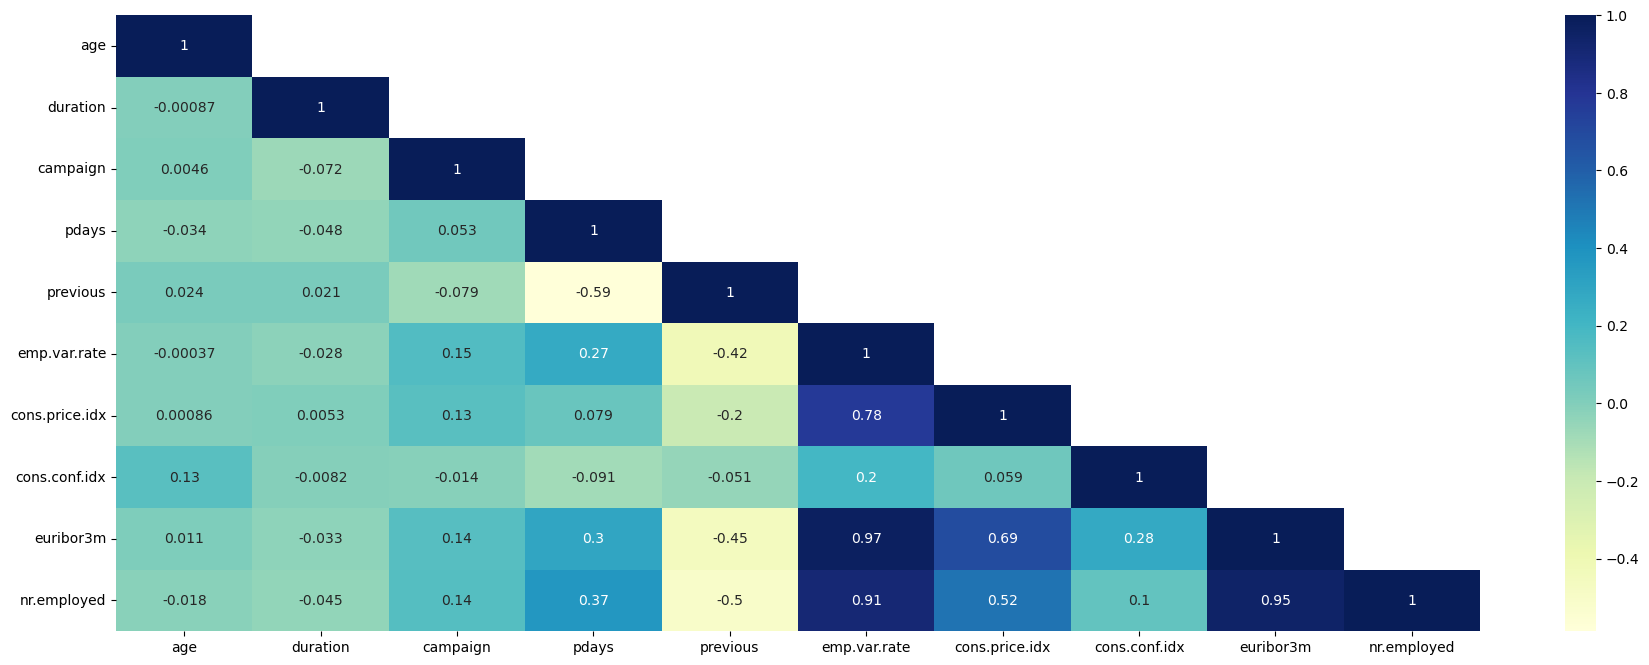

In [175]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(22,8))
corr_df = corr = df.corr(numeric_only=True,method='pearson')
df_lt = corr_df.where(np.tril(np.ones(corr_df.shape)).astype(bool))
hmap = sns.heatmap(df_lt, cmap='YlGnBu',annot=True)

# Eliminar variables que tengan alta correlación y/o no sean necesarias

Las variables que presentan una correlación mayor a 0.9 son:
euribor3m y emp.var.rate tienen una correlación de 0.97
euribor3m y nr.employed tienen una correlación de 0.95
nr.employed y emp.var.rate tienen una correlación de 0.91
No es necesario conservar las tres variables, ya que contienen información muy similar y pueden generar problemas de multicolinealidad en el modelo.
Por ello, se pueden eliminar dos variables y conservar únicamente una como representante de este grupo de variables altamente correlacionadas.
En este caso, se decidió conservar la variable nr.employed y eliminar:
euribor3m
emp.var.rate

In [176]:
df2 = df2.drop(columns=['euribor3m','emp.var.rate'])

In [177]:
# una muestra del dataset
df2.sample(5)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,cons.price.idx,cons.conf.idx,nr.employed,y,duration-log,campaign-log,previous-log,previously_contacted
21080,1.341116,self-employed,married,high.school,no,yes,no,cellular,aug,thu,...,0,nonexistent,-0.227465,0.951267,0.845170,0,-0.275981,0.543966,-0.38141,0
5801,0.285568,management,married,university.degree,no,yes,no,telephone,may,mon,...,0,nonexistent,0.722722,0.886447,0.331680,0,-0.466890,-0.041472,-0.38141,0
2304,-0.674021,technician,divorced,high.school,no,no,no,telephone,may,tue,...,0,nonexistent,0.722722,0.886447,0.331680,0,0.179406,-0.866600,-0.38141,0
28989,0.093650,blue-collar,married,unknown,unknown,yes,no,cellular,apr,fri,...,0,nonexistent,-0.864955,-1.425496,-0.940281,0,0.895301,0.543966,-0.38141,0
19711,-0.290186,housemaid,married,high.school,unknown,no,yes,cellular,aug,thu,...,0,nonexistent,-0.227465,0.951267,0.845170,0,1.209727,-0.041472,-0.38141,0


# Cambiar las variables de tipo de dato objeto a tipo de dato categórico para usarse para el Machine Learning. 

In [178]:
df2['job'] = df2['job'].astype('category')
df2['marital'] = df2['marital'].astype('category')
df2['education'] = df2['education'].astype('category')

df2['default'] = df2['default'].astype('category')
df2['housing'] = df2['housing'].astype('category')
df2['loan'] = df2['loan'].astype('category')

df2['contact'] = df2['contact'].astype('category')
df2['month'] = df2['month'].astype('category')
df2['day_of_week'] = df2['day_of_week'].astype('category')

df2['poutcome'] = df2['poutcome'].astype('category')
df2['y'] = df2['y'].astype('category')

# Checar el tipo de datos

In [179]:
df2.dtypes

age                      float64
job                     category
marital                 category
education               category
default                 category
housing                 category
loan                    category
contact                 category
month                   category
day_of_week             category
duration                   int64
campaign                   int64
pdays                      int64
previous                   int64
poutcome                category
cons.price.idx           float64
cons.conf.idx            float64
nr.employed              float64
y                       category
duration-log             float64
campaign-log             float64
previous-log             float64
previously_contacted       int64
dtype: object

In [180]:
cols_num = [
    'age',
    'duration-log',
    'campaign-log',
    'cons.price.idx',
    'cons.conf.idx',
    'nr.employed'
]

# Distribuciones de las variables

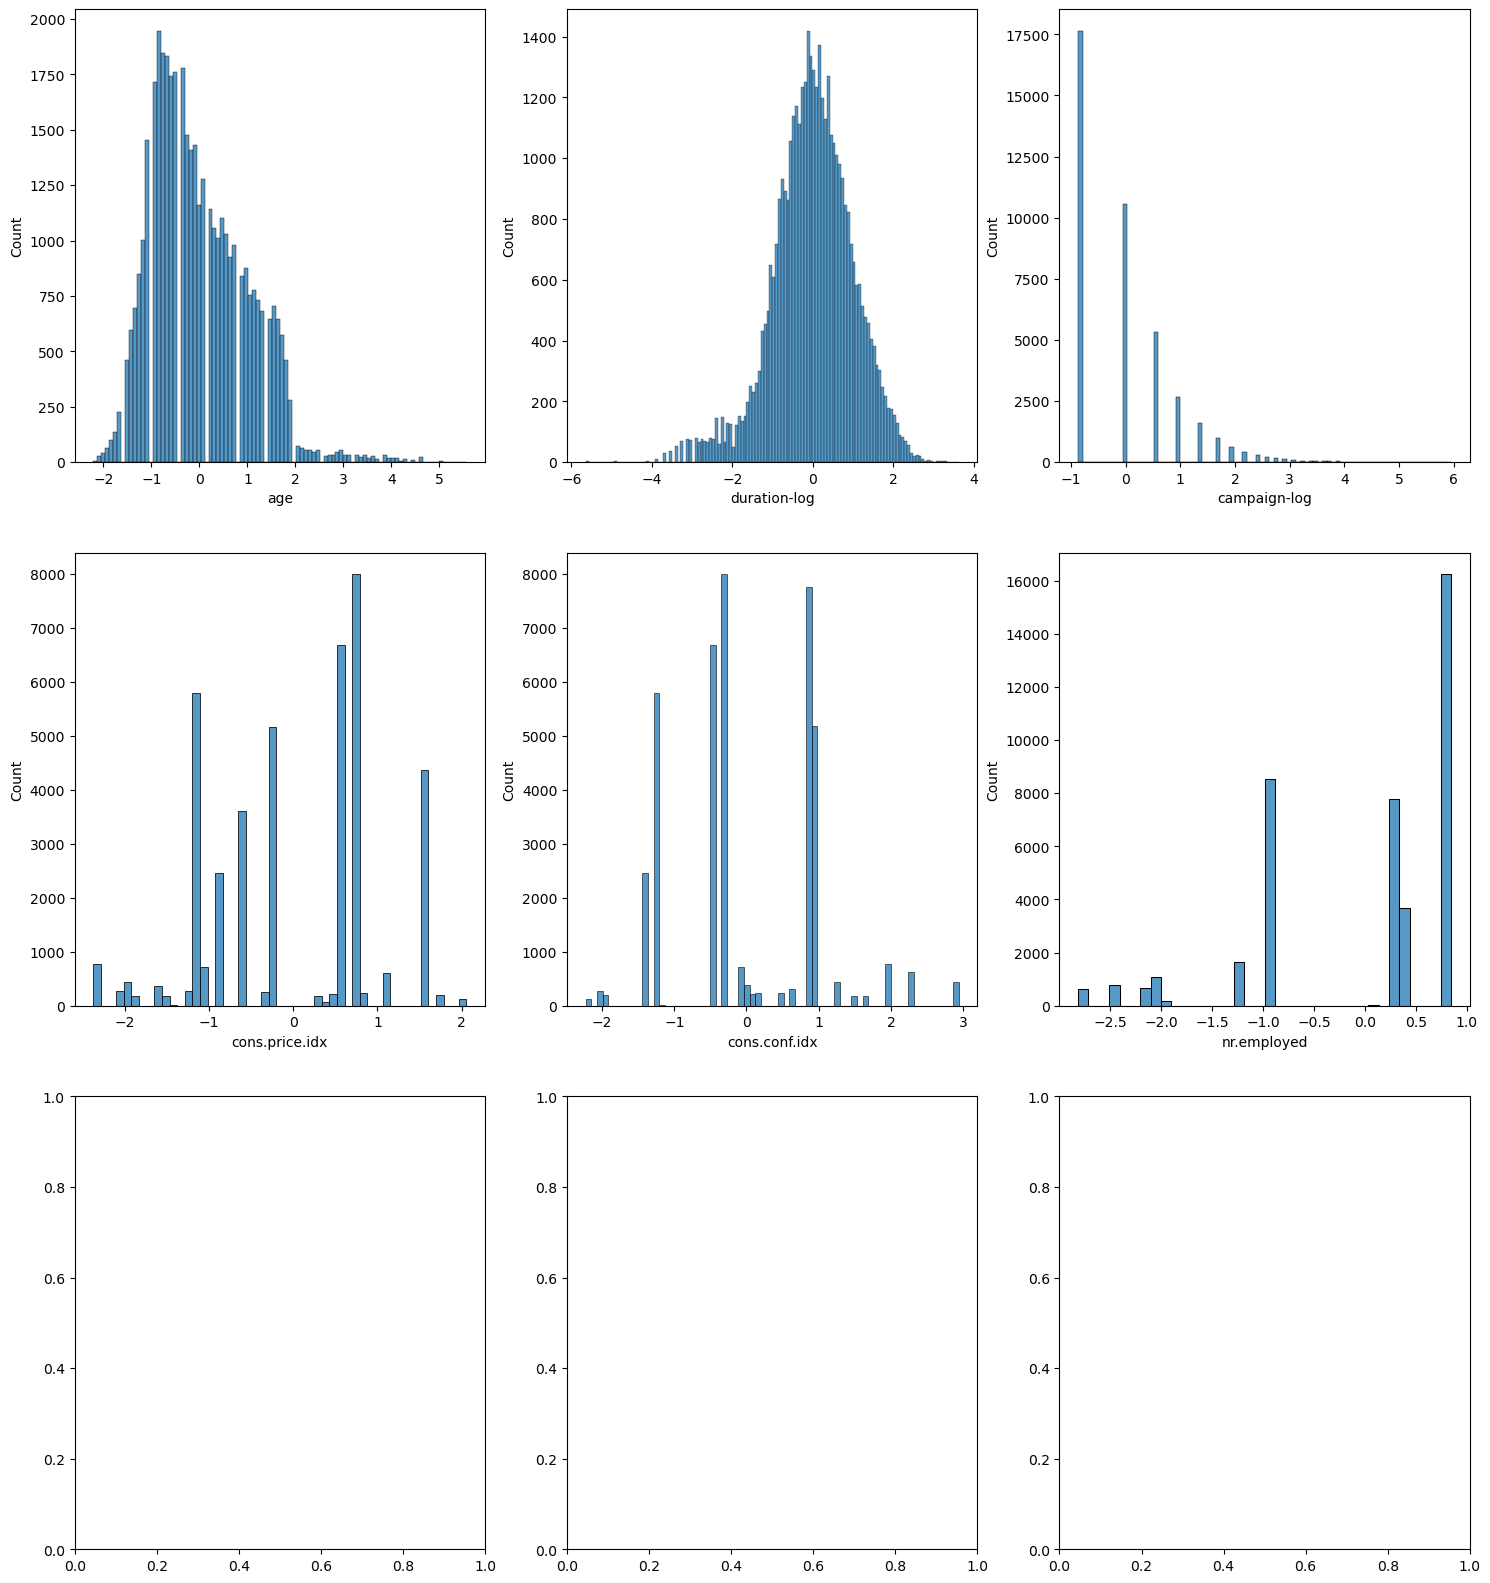

In [181]:
fig, axes = plt.subplots(nrows= 3, ncols=3, figsize=(18,20))
for i, column in enumerate(cols_num):
    sns.histplot(df2[column],ax=axes[i//3,i%3],kde=False)

In [182]:
# una muestra
df2.sample()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,cons.price.idx,cons.conf.idx,nr.employed,y,duration-log,campaign-log,previous-log,previously_contacted
39291,0.573445,unemployed,single,university.degree,no,no,no,cellular,mar,tue,...,2,success,-0.357036,1.232158,-2.191481,1,0.439417,-0.8666,3.500468,1


# Dividir dataset entre training y test (70:30) 

In [183]:
from sklearn.model_selection import train_test_split

X = df2.drop('y', axis=1)
y = df2['y']

X = pd.get_dummies(X, drop_first = True)
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=1)

In [184]:
X_train.head(3)

,age,duration,campaign,pdays,previous,cons.price.idx,cons.conf.idx,nr.employed,duration-log,campaign-log,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
11196,-0.194227,149,1,999,0,1.536429,-0.280328,0.845170,-0.177114,-0.8666,...,False,False,False,False,False,True,False,False,True,False
15464,1.053240,104,1,999,0,0.591424,-0.474791,0.845170,-0.566103,-0.8666,...,False,False,False,False,False,False,False,False,True,False
25538,0.477486,770,1,999,0,-0.649003,-0.323542,0.398115,1.608256,-0.8666,...,False,True,False,False,False,False,False,True,True,False


In [185]:
y_train.head(3)

11196    0
15464    0
25538    0
Name: y, dtype: category
Categories (2, int64): [0, 1]

In [186]:
X_test.head(3)

,age,duration,campaign,pdays,previous,cons.price.idx,cons.conf.idx,nr.employed,duration-log,campaign-log,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
35577,-0.769980,114,1,999,0,-1.179380,-1.231034,-0.940281,-0.466890,-0.866600,...,True,False,False,False,True,False,False,False,True,False
13950,-0.674021,103,2,999,0,0.591424,-0.474791,0.845170,-0.576540,-0.041472,...,False,False,False,False,False,False,False,False,True,False
29451,-1.441693,227,5,999,0,-0.864955,-1.425496,-0.940281,0.279532,1.369094,...,False,False,False,False,True,False,False,False,True,False


In [187]:
y_test.head(3)

35577    0
13950    0
29451    1
Name: y, dtype: category
Categories (2, int64): [0, 1]

In [188]:
print("{0:0.2f}% data is in training set".format((len(X_train)/len(df2.index))*100))
print("{0:0.2f}% data is in test set".format((len(X_test)/len(df2.index))*100))

70.00% data is in training set
30.00% data is in test set


In [189]:
print("Original Personal Loan True Values : {0} ({1:02}%)".format(len(df2.loc[df2['y']=='yes']),(len(df2.loc[df2['y']=='yes'])/len(df2.index))*100))
print("Original Personal Loan False Values : {0} ({1:02}%)".format(len(df2.loc[df2['y']=='no']),(len(df2.loc[df2['y']=='no'])/len(df2.index))*100))
print("")
print("Training Personal Loan True Values : {0} ({1:02}%)".format(len(y_train.loc[y_train[:]=='yes']),(len(y_train.loc[y_train[:]=='yes'])/len(y_train))*100))
print("Training Personal Loan False Values : {0} ({1:02}%)".format(len(y_train.loc[y_train[:]=='no']),(len(y_train.loc[y_train[:]=='no'])/len(y_train))*100))
print("")
print("Training Personal Loan True Values : {0} ({1:02}%)".format(len(y_test.loc[y_test[:]=='yes']),(len(y_test.loc[y_test[:]=='yes'])/len(y_test))*100))
print("Training Personal Loan False Values : {0} ({1:02}%)".format(len(y_test.loc[y_test[:]=='no']),(len(y_test.loc[y_test[:]=='no'])/len(y_test))*100))


Original Personal Loan True Values : 0 (0.0%)
Original Personal Loan False Values : 0 (0.0%)

Training Personal Loan True Values : 0 (0.0%)
Training Personal Loan False Values : 0 (0.0%)

Training Personal Loan True Values : 0 (0.0%)
Training Personal Loan False Values : 0 (0.0%)


# Simple modelo de regresión logística

In [190]:
from sklearn import metrics 
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight={0:0.15,1:0.85},solver='liblinear')
model.fit(X_train, y_train)

y_predict = model.predict(X_test)

In [191]:
y_predict[:100]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [192]:
z = X_test.copy()
z['Response real'] = y_test
z['Response predicción'] = y_predict
z[['Response real','Response predicción']].head(10)
 

,Response real,Response predicción
35577,0,0
13950,0,0
29451,1,0
32295,0,0
27477,0,0
31507,0,0
32167,0,0
24580,0,0
2954,0,0
34998,0,0


In [193]:
coef_df = pd.DataFrame(model.coef_)
coef_df.columns = X.columns
coef_df['intercept'] = model.intercept_
coef_df.T

,0
age,0.021868
duration,0.001480
campaign,0.025450
pdays,-0.002118
previous,0.281224
cons.price.idx,-0.290845
cons.conf.idx,0.027778
nr.employed,-1.149637
duration-log,1.830117
campaign-log,-0.151175


# Matriz de confusión

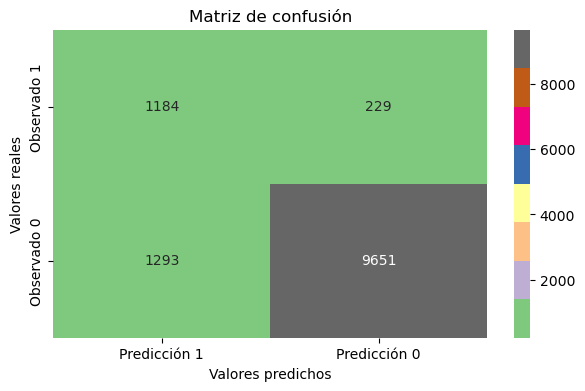

In [194]:
import matplotlib.pyplot as plt
from sklearn import metrics

cm = metrics.confusion_matrix(y_test, y_predict, labels=[1,0])

df_cm = pd.DataFrame(
    cm,
    index=['Observado 1', 'Observado 0'],
    columns=['Predicción 1', 'Predicción 0']
)

plt.figure(figsize=(7,4))

sns.heatmap(df_cm, annot=True, cmap='Accent', fmt='d')

plt.title('Matriz de confusión')
plt.ylabel('Valores reales')
plt.xlabel('Valores predichos')

plt.show()

In [195]:
df_cm

,Predicción 1,Predicción 0
Observado 1,1184,229
Observado 0,1293,9651


In [196]:
TP = df_cm.iloc[0][0]
FP = df_cm.iloc[0][1]
FN = df_cm.iloc[1][0]
TN = df_cm.iloc[1][1]

print('TP=',TP,'FN=',FN,'FP=',FP,'TN=',TN)


TP= 1184 FN= 1293 FP= 229 TN= 9651


/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_74266/2518295390.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  TP = df_cm.iloc[0][0]
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_74266/2518295390.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  FP = df_cm.iloc[0][1]
/var/folders/gb/nv8xcn1n2fj8nvh2rrjytk0r0000gn/T/ipykernel_74266/2518295390.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  FN = df_

El modelo predijo correctamente 1184 clientes que sí aceptaron la campaña (TP).
El modelo clasificó incorrectamente 1293 clientes que sí aceptaron la campaña como si no la hubieran aceptado (FN).
El modelo clasificó incorrectamente 229 clientes que no aceptaron la campaña como si sí la hubieran aceptado (FP).
El modelo predijo correctamente 9651 clientes que no aceptaron la campaña (TN).
Esto indica que el modelo tiene un buen desempeño identificando clientes que no aceptan la campaña, debido al alto número de verdaderos negativos y al bajo número de falsos positivos. Sin embargo, presenta dificultades para detectar correctamente a los clientes que sí aceptan la campaña, ya que los falsos negativos son relativamente altos.

# Cálculo de primeras medidas de calidad del modelo: Accuracy, Precision, Recall, F1 

In [197]:
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score,roc_auc_score,classification_report,confusion_matrix

y_pred = model.predict(X_test)
model_score =accuracy_score(y_test,y_pred)
recall_score = recall_score(y_test,y_pred)
precision_score = precision_score(y_test,y_pred)
f1_score = f1_score(y_test,y_pred)
roc_auc_score = roc_auc_score(y_test,y_pred)

print('Medidas del modelo')
print('-------------------------------------')
print('Accuracy = {0:0.2f}'.format(model_score))
print('Precision = {0:0.2f}'.format(precision_score))
print('Recall = {0:0.2f}'.format(recall_score))
print('f1_score = {0:0.2f}'.format(f1_score))
print('Roc Auc Score = {0:0.2f}'.format(roc_auc_score))

Medidas del modelo
-------------------------------------
Accuracy = 0.88
Precision = 0.48
Recall = 0.84
f1_score = 0.61
Roc Auc Score = 0.86


# Conclusiones

El modelo clasifica correctamente el 88% de las observaciones totales.
De todos los clientes que el modelo predijo que aceptarían la campaña, solo el 48% realmente la aceptó. Esto indica una cantidad considerable de falsos positivos.
El modelo logra identificar correctamente el 84% de los clientes que sí aceptaron la campaña, mostrando una alta sensibilidad para detectar casos positivos.
El F1-score refleja un equilibrio moderado entre precisiín y recall. Aunque el recall es alto, la precisión relativamente baja reduce el valor del F1-score.
El modelo presenta una excelente capacidad de discriminación entre clientes que aceptan y no aceptan la campaña. 
El modelo está orientado a maximizar la detección de clientes potencialmente interesados en la campaña, lo que se refleja en el recall alto. Sin embargo, esto ocurre a costa de una menor precisión, generando  más falsos positivos. 
